# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [5]:
data_base_path = "asl_data/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [6]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [7]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

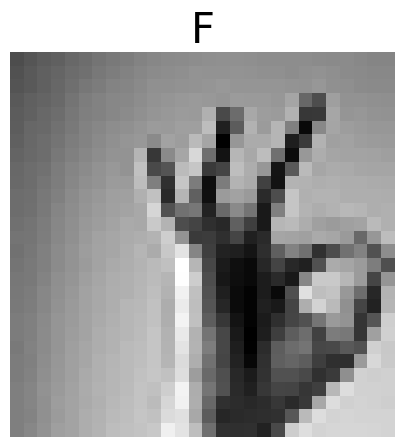

In [8]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [9]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [10]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [11]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [12]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [13]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [14]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [15]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [16]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [01:12<00:00,  3.62s/epoch, train_acc=0.8744, train_loss=0.3556, val_acc=0.7434, val_loss=0.9091]


In [17]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

In [33]:
print(fcnn_test_loss, fcnn_test_acc)

0.8874108300685085 0.7414947016174


### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [18]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [19]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [01:26<00:00,  4.30s/epoch, train_acc=0.9981, train_loss=0.0052, val_acc=0.9473, val_loss=0.2216]


In [31]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

In [32]:
print(cnn_test_loss, cnn_test_acc)

0.2001449612578474 0.9436698271054077


## Reflection section

Respondere en espanol porque no se ingles hajah

### Which model is better at classifying ASL images?

Okay yo esperaba que el mejor modelo obviamente fuera la convolutional neural network (CNN) y claramente fue asi, pero por MUCHO. Literalmente la red neuronal fully conected pero que no tenia convoluciones ni layers de pooling obtuvo un validation acc de 0.7434, lo cual la verdad generaliza no de una manera tan pobre, pero si ya anda batallando un poco. En cambio la CNN obtuvo un validation acc de 0.9473 lo cual es INCREIBLE, es mucho mejor, y claramente ya que estas redes neuronales estan disenadas para extraer patrones de la imagen, y se entrenan para mejorar la extraccion de estos patrones. Este experimento confirma tambien el boom de las redes neuronales convolucionales y porque la gente las prefiere la mayoria de las veces para tareas de imagenes mas que computacion de vision por computadora puro, aplicando los filtros tu solo, etc. 

Acabo de correr los test loss y accs y sigue siendo lo mismo la CNN es mejor con 0.94 de test accuracy, mientras que la NN Fully connected toma 0.74 de test accuracy

### Which model was _faster_ to train?

El modelo mas rapido para entrenar fue la red neuronal fully connected , ya que tardo 1 minuto y 14 segundos, la verdad es que no hay una diferencia muy grande entre la NN fully connected y la CNN, ya que la CNN se entreno en 1 minuto con 26 segundos, basicamente 12 segundos mas y valio la pena esperar esos 12 segundos mas porque nos dio un rendimiento muy superior a la NN fully connected. Tambien tiene sentido que la CNN tardara mas en entrenar ya que tiene mas layers, creo que la NN Fully Connected tenia solamente 3 layers lineares? Mientras que la CNN tiene mas de 6 incluyendo las layers de convolucion y las de pooling


### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

In [41]:
import matplotlib.pyplot as plt

def plot_learning_curves(train_history):
    range_epochs = 20
    epochs = range(1, range_epochs +1 )

    plt.plot(epochs, train_history['train_loss'], label="Curva de perdida del entrenamiento")
    plt.plot(epochs, train_history['val_loss'], label="Curva de perdida de validacion")
    plt.xlabel("Epoch")
    plt.ylabel("Perdida")
    plt.title("Curvas de perdida")
    plt.legend()
    plt.show()


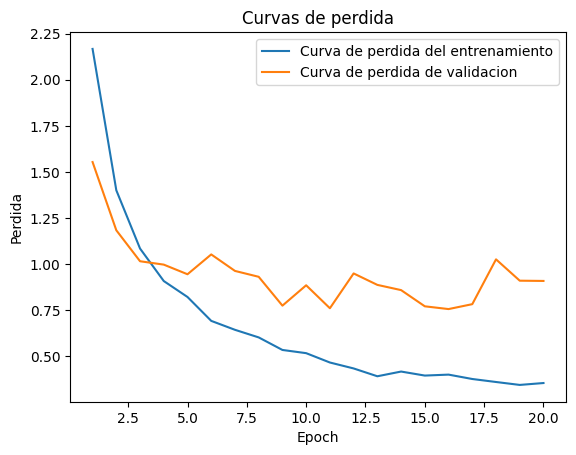

In [44]:
plot_learning_curves(fcnn_res) 

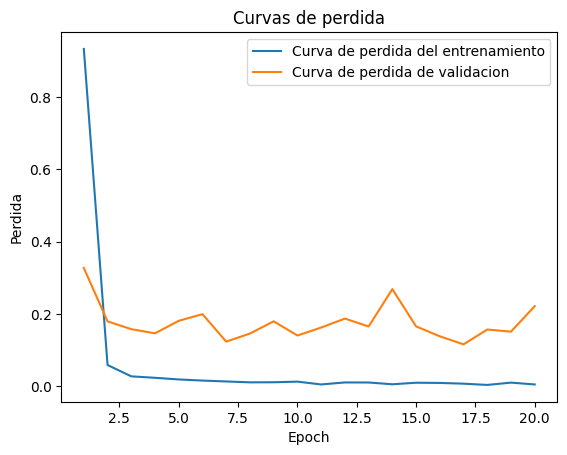

In [43]:
plot_learning_curves(cnn_res)

Okay aun que ya sabemos que la CNN le fue mucho mejor que la NN FULLY CONNECTED (NNFC), el drop de la curva de perdida en entrenamiento es mucho mas suave en la NNFC, en la CNN fue muy rapido entonces sugiere que existe overfitting. Ahora, al pasar de los epochs la NNFC tambien creo que llego a tener overfitting pero definitivamente la CNN no tardo nada en tenerlo. Tuvimos mejores curvas tanto de perdida en train tanto como en val para la CNN, la NNFC llego a bajar en la curva de entrenamiento casi lo mismo para la de la CNN en los ultimos epochs, mas sin embargo la curva de perdida de validacion si se quedo muy arriba. Quiza reduciendo layers de la CNN o implementando otra tecnica para prevenir overfitting nos vaya mejor? aunque nos fue super bien y ya usamos dropout en la arquitectura

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

In [46]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("FCNN trainable parameters:", count_trainable_parameters(model_fcnn))
print("CNN trainable parameters:", count_trainable_parameters(model_cnn))

FCNN trainable parameters: 676888
CNN trainable parameters: 403799


### How do the models compare in terms of overfitting? Why do you think that is the case?

Bueno, creo que los 2 modelos no se comparan en overfitting, porque como menciono, el overfitting en la CNN es muy notorio desde el principio, mas sin embargo siento que el overfitting en la NNFC alcanzo o incluso fue peor que el de la CNN al final, entonces en general dijera que no se comparan, pero en los epochs finales del 17 para adelante pudiera decir que se comparan y hasta le fue peor a la NNFC en overfitting, sugiriendo que ya alcanzo su apogeo en val acc o val loss la NNFC porque aunque entrenemos mas seguira en lo mismo posiblemente porque ya esta overfitteando, sin emargo la CNN si fue volatil en el train acc regardless del overfitting. Quiza modificar la arquitectura ayude en cualquiera de los 2 casos, en una incrementar capas y en la otra implementar mas tecnicas contra el overfitting. 

### Final conclusions and remarks

Definitivamente esta actividad nos ayuda a reforzar que las CNNs en la mayoria de los casos son mas utiles que las NNFCs pero tambien nos ayudo a indagar mas en los resultados como el overfitting, plottear las curvas de aprendizaje, y pensar en posibles mejoras. Tambien al saber el numero de parametros posibles para entrenar en cada red neuronal tambien me puedo dar cuenta que aunque la FCNN jajaja yo le estaba diciendo NNFC ay no jajaj. aunque la FCNN tiene mas parametros que la CNN aun asi no generaliza bien ya que en su val acc y test acc quedo muy pobre y es overpowered por la CNN, dandonos tambien a entender o reflexionar mas sobre la idea de que no siempre es la cantidad de parametros la formula ganadora, si no como los utilizas, por ejemplo la CNN esta optimizada para imagenes ya que tiene redes de convolucion y de pooling, y aunque no tenemos tantos parametros como la FCNN, aun asi nos fue MUCHISIMO mejor, esto indica que la CNN fue la red correcta para nuestro problema, por eso es IMPORTANTE saber identificar que tipo de problema estamos abordando ya que hasta cierto punto no va a importar la cantidad de capas si no como las usamos. Tambien esta misma idea puede ayudar porque si estamos teniendo un mal rendimiento en cierto problema especifico, en vez de agregar mas neuronas o capas a lo loco, podremos ahora reflexionar sobre si la arquitectura es la adecuada para el problema y en vez de solo agregar mas parametros, mejor optimizar la arquitcecture como tal.

Me gusto mucho la actividad como primer acercamiento a las CNNs y tambien para hacerme pensar sobre otra manera para abordar problemas donde estoy teniendo mal performance en mi metrica objetivo, en vez de agregar mas capas y parametros, optimizar la arquitectura al problema especifico. 